In [ ]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 770.1 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 131.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 87.3 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


In [1]:
from __future__ import print_function
import keras
from keras.datasets import cifar10
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation
from keras.layers import Conv2D, MaxPooling2D, GlobalMaxPooling2D,BatchNormalization
from sklearn.metrics import confusion_matrix
import seaborn as sns


In [2]:
batch_size = 32
num_classes = 10
data_augmentation = True

In [3]:
# The data, shuffled and split between train and test sets:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print('x_train shape:', x_train.shape)
print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
x_train shape: (50000, 32, 32, 3)
50000 train samples
10000 test samples


In [4]:
# Convert class vectors to binary class matrices.
y_train = keras.utils.to_categorical(y_train, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

In [5]:
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255

In [17]:
model = Sequential()

# Convolutional layer with 32 filters, each of size 3x3
model.add(Conv2D(32, (3, 3), kernel_initializer='random_uniform', input_shape=x_train.shape[1:]))
# ReLU activation function
model.add(Activation('relu'))
# Batch normalization layer
model.add(BatchNormalization())

model.add(Conv2D(48, (3, 3), kernel_initializer='random_uniform'))
model.add(Activation('relu'))
model.add(BatchNormalization())

model.add(Conv2D(64, (3, 3), kernel_initializer='random_uniform'))
model.add(Activation('relu'))
model.add(BatchNormalization())

model.add(Conv2D(128, (3, 3), kernel_initializer='random_uniform'))
model.add(Activation('relu'))
model.add(BatchNormalization())

# Global max pooling layer
model.add(GlobalMaxPooling2D())
# Dropout layer with dropout rate of 0.25
model.add(Dropout(0.25))

# Fully connected layer with number of units equal to the number of classes
model.add(Dense(num_classes))
# Softmax activation function for multi-class classification
model.add(Activation('softmax'))

# Print the model summary
model.summary()

# Compile the model with the Adamax optimizer
opt = keras.optimizers.Adamax(learning_rate=0.001)
model.compile(loss='categorical_crossentropy',
              optimizer=opt,
              metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [10]:
if not data_augmentation:
    print('Not using data augmentation.')
    history = model.fit(x_train, y_train,
              batch_size=batch_size,
              epochs=25,
              validation_data=(x_test, y_test),
              shuffle=True)
else:
    print('Using real-time data augmentation.')
    # This will do preprocessing and realtime data augmentation:
    datagen = ImageDataGenerator(
        featurewise_center=False,  # set input mean to 0 over the dataset
        samplewise_center=False,  # set each sample mean to 0
        featurewise_std_normalization=False,  # divide inputs by std of the dataset
        samplewise_std_normalization=False,  # divide each input by its std
        zca_whitening=False,  # apply ZCA whitening
        zca_epsilon=1e-06,  # epsilon for ZCA whitening
        rotation_range=0,  # randomly rotate images in the range (degrees, 0 to 180)
        width_shift_range=0.1,  # randomly shift images horizontally (fraction of total width)
        height_shift_range=0.1,  # randomly shift images vertically (fraction of total height)
        horizontal_flip=True,  # randomly flip images
        vertical_flip=False)  # randomly flip images

    # Compute quantities required for feature-wise normalization
    # (std, mean, and principal components if ZCA whitening is applied).
    datagen.fit(x_train)

    # Fit the model on the batches generated by datagen.flow().
    history = model.fit(datagen.flow(x_train, y_train, batch_size=batch_size),
                        epochs=10,
                        validation_data=(x_test, y_test),
                        steps_per_epoch=x_train.shape[0] // batch_size)


Using real-time data augmentation.
Epoch 1/10
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 731s 468ms/step - accuracy: 0.2551 - loss: 2.2437 - val_accuracy: 0.4161 - val_loss: 1.6699
Epoch 2/10
   1/1562 ━━━━━━━━━━━━━━━━━━━━ 10:38 409ms/step - accuracy: 0.2500 - loss: 2.2293

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1562/1562 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.2500 - loss: 2.2293 - val_accuracy: 0.4160 - val_loss: 1.6619
Epoch 3/10
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 719s 461ms/step - accuracy: 0.3539 - loss: 1.8135 - val_accuracy: 0.5018 - val_loss: 1.4207
Epoch 4/10
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.4688 - loss: 1.3621 - val_accuracy: 0.5025 - val_loss: 1.4225
Epoch 5/10
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 718s 460ms/step - accuracy: 0.4265 - loss: 1.5983 - val_accuracy: 0.5232 - val_loss: 1.3479
Epoch 6/10
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.4062 - loss: 1.3707 - val_accuracy: 0.5248 - val_loss: 1.3416
Epoch 7/10
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 762s 456ms/step - accuracy: 0.4730 - loss: 1.4637 - val_accuracy: 0.5550 - val_loss: 1.2686
Epoch 8/10
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.4375 - loss: 1.5581 - val_accuracy: 0.5557 - val_loss: 1.2634
Epoch 9/10
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 773s 464ms/step - accuracy: 0.5042 - lo

In [12]:
print(history.history['accuracy'])
print(history.history['val_accuracy'])

[0.2551032602787018, 0.25, 0.35392650961875916, 0.46875, 0.426472932100296, 0.40625, 0.4729827046394348, 0.4375, 0.5041626691818237, 0.46875]
[0.41609999537467957, 0.41600000858306885, 0.501800000667572, 0.5024999976158142, 0.5231999754905701, 0.5248000025749207, 0.5550000071525574, 0.5557000041007996, 0.5666999816894531, 0.5631999969482422]


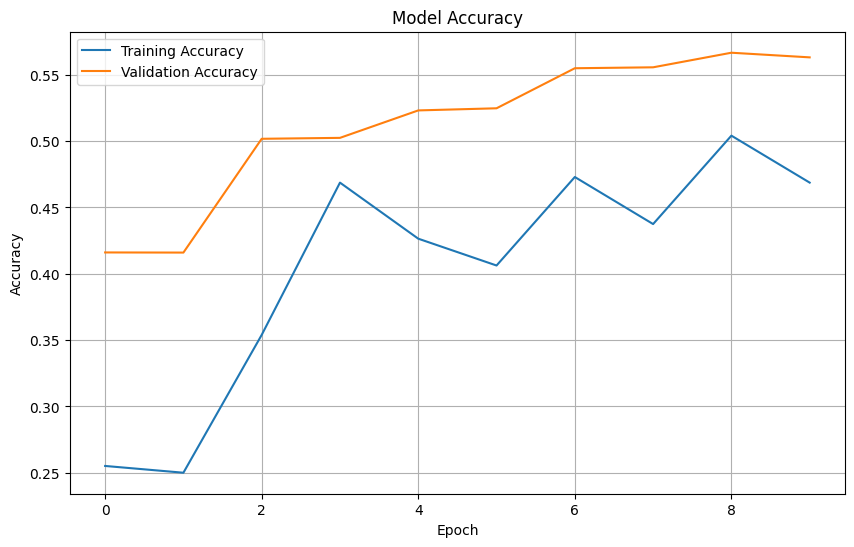

In [13]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.grid(True)
plt.show()

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import random

def predict():
    # Randomly select an index from the test set
    idx = random.randint(0, len(x_test) - 1)

    # Select the image and its corresponding label
    image = x_test[idx]
    actual_label = y_test[idx]

    # Make predictions using the trained model
    predictions = model.predict(np.expand_dims(image, axis=0))
    predicted_label = np.argmax(predictions)

    # Define class names (assuming num_classes is defined)
    class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                  'dog', 'frog', 'horse', 'ship', 'truck']


    # Display the image
    plt.figure(figsize=(1,1))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f'Actual: {class_names[np.argmax(actual_label)]}, Predicted: {class_names[predicted_label]}')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


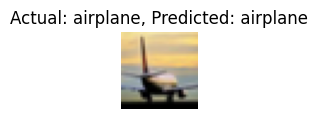

In [21]:
predict()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


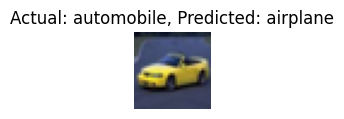

In [22]:
predict()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


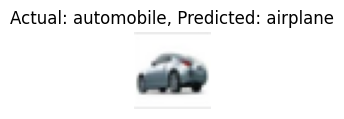

In [23]:
predict()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


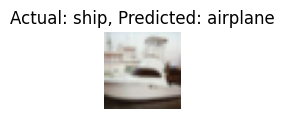

In [19]:
predict()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


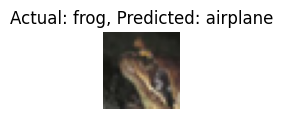

In [20]:
predict()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


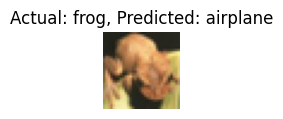

In [24]:
predict()

In [1]:
!git clone https://github.com/jay-123-oss/deep-learning-implementation.git

Cloning into 'deep-learning-implementation'...
remote: Enumerating objects: 18, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 18 (delta 2), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (18/18), 463.17 KiB | 3.68 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [2]:
%cd deep-learning-implementation

/content/deep-learning-implementation


In [3]:
!git pull origin main

From https://github.com/jay-123-oss/deep-learning-implementation
 * branch            main       -> FETCH_HEAD
Already up to date.


In [4]:
!mkdir image_classification


In [10]:
# notebook copy
!cp image_classification.ipynb image_classification/

# dataset copy
!cp /content/data.csv image_classification/

cp: cannot stat 'image_classification.ipynb': No such file or directory
